# Deep Hedging with a Residual Correction Network
## Entropic Risk Measure · GBM · Proportional Transaction Costs

This notebook implements the deep-hedging framework of Bühler et al. (2018) for
hedging a **short European call** under **geometric Brownian motion** with
**proportional transaction costs**.

### Key idea
Rather than learning the hedge ratio from scratch, we parametrize it as:

$$\delta_k = \Delta^{\text{BS}}(t_k, S_{t_k}) + F_\theta(t_k, \log(S_{t_k}/K), \epsilon_{k-1})$$

where $\Delta^{\text{BS}}$ is the analytic Black-Scholes delta (hardcoded) and
$F_\theta$ is a small MLP that learns the *correction* needed under transaction
costs.  At initialisation the output layer is zeroed, so training begins from
the Black-Scholes policy.

### Risk measure
We minimise the **entropic risk measure**:

$$\rho_\lambda(X) = \frac{1}{\lambda}\log\,\mathbb{E}\!\left[e^{-\lambda X}\right]$$

This is the certainty-equivalent loss for an agent with constant absolute risk
aversion $\lambda$.  Minimising $\rho_\lambda(\text{PL}_T)$ over the network
weights is equivalent to maximising expected exponential utility.

### Parameters
| Symbol | Value(s) | Description |
|--------|-------|-------------|
| $S_0$ | 340 | Initial stock price |
| $\sigma$ | 0.24 | GBM volatility |
| $\mu$ | 0.08 | Drift |
| $K$ | 340 | Strike (at-the-money) |
| $T$ | 1 year | Maturity |
| $n$ | 252 | Trading steps (daily) |
| $\lambda$ | 0.05, 0.1, 0.2, 0.5, 1 | Risk-aversion parameter |
| $c$ | 0.001 | Proportional transaction cost (0.1%) |

---


In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm as scipy_norm

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available (falls back to CPU silently)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 1. Global Parameters

In [2]:
# ── Market parameters ──────────────────────────────────────────────────────────
S0    = 340.0    # Initial stock price
K     = 340.0    # Strike price (at-the-money)
SIGMA = 0.24     # GBM annual volatility (same under P and Q)
MU    = 0.08     # GBM annual drift under P (8% p.a.)
R     = 0.0      # Risk-free rate (set to zero for simplicity)
T     = 1.0      # Time to maturity (years)

# ── Discretisation ─────────────────────────────────────────────────────────────
N_STEPS = 252    # Trading steps (one per business day)
DT      = T / N_STEPS

# ── Risk measure ───────────────────────────────────────────────────────────────
# The entropic risk measure is:
#   rho_lambda(X) = (1/lambda) * log E_P[exp(-lambda * X)]
# Taylor expansion: rho_lambda(X) ≈ -E_P[X] + (lambda/2) * Var_P(X)
#
# LAMBDA_LEVELS: the sweep values used in Section 7 (lambda sweep).
# LAMBDA: the single value used in Sections 8-10 for detailed visualisation.
LAMBDA_LEVELS = [0.05, 0.1, 0.2, 0.5, 1.0]   # sweep range
LAMBDA        = 0.1                             # default for detailed analysis

# ── Transaction costs ──────────────────────────────────────────────────────────
# Proportional cost: c * S_k * |delta_k - delta_{k-1}|
# 0.001 = 0.1% of notional per trade.
COST_RATE = 0.001

# ── Training hyperparameters ───────────────────────────────────────────────────
M_PATHS       = 4_000    # Paths per gradient step
N_STEPS_TR    = 1_000    # Gradient steps for the main (single-lambda) training run
N_STEPS_SWEEP = 1_000    # Gradient steps per lambda in the sweep
LR            = 1e-3     # Adam learning rate
VAL_PATHS     = 50_000   # Fixed validation set size (under P)
LOG_EVERY     = 100      # Print every this many steps

print("Parameters loaded.")
print(f"  Physical measure P: mu={MU}, sigma={SIGMA}")
print(f"  Lambda sweep: {LAMBDA_LEVELS}")
print(f"  Default lambda for detailed analysis: {LAMBDA}")
print(f"  dt = {DT:.6f}")


Parameters loaded.
  Physical measure P: mu=0.08, sigma=0.24
  Lambda sweep: [0.05, 0.1, 0.2, 0.5, 1.0]
  Default lambda for detailed analysis: 0.1
  dt = 0.003968


## 2. Black-Scholes Utilities

We need two things from the Black-Scholes model:

1. **Delta** $\Delta^{\text{BS}}(t, S) = N(d_1)$  — the analytic hedge ratio, used at every
   timestep as the baseline for the correction network.
2. **Call price** $C^{\text{BS}}(0, S_0)$ — used as the initial premium $p_0$ received for
   selling the option.  Under the entropic risk measure, the fair price could in principle
   be solved jointly, but fixing it at the BS price is standard for comparing against
   the BS delta-hedger.


In [3]:
# ── Black-Scholes analytic formulas ───────────────────────────────────────────

def bs_d1(t: torch.Tensor, S: torch.Tensor,
          K: float = K, sigma: float = SIGMA, r: float = R) -> torch.Tensor:
    """
    Compute d1 in the Black-Scholes formula.

    d1 = [log(S/K) + (r + sigma^2/2) * tau] / (sigma * sqrt(tau))

    Parameters
    ----------
    t     : current time (fraction of year, shape [M])
    S     : current stock price (shape [M])
    K     : strike price (scalar)
    sigma : volatility (scalar)
    r     : risk-free rate (scalar)

    Returns
    -------
    d1 : shape [M]
    """
    tau = torch.clamp(torch.tensor(T) - t, min=1e-8)  # time remaining
    log_moneyness = torch.log(S / K)
    return (log_moneyness + (r + 0.5 * sigma ** 2) * tau) / (sigma * torch.sqrt(tau))


def bs_delta(t: torch.Tensor, S: torch.Tensor,
             K: float = K, sigma: float = SIGMA, r: float = R) -> torch.Tensor:
    """
    Black-Scholes delta for a European call: Delta = N(d1).

    This is the fraction of one share to hold in order to delta-hedge
    a short call in a frictionless complete market.

    Returns
    -------
    delta : shape [M], values in (0, 1)
    """
    d1 = bs_d1(t, S, K, sigma, r)
    # N(x) = (1 + erf(x/sqrt(2))) / 2, implemented via torch.erf for autograd
    return 0.5 * (1.0 + torch.erf(d1 / (2.0 ** 0.5)))


def bs_call_price(S0: float, K: float = K, sigma: float = SIGMA,
                  r: float = R, T: float = T) -> float:
    """
    Black-Scholes call price via the closed-form formula.

    C = S0 * N(d1) - K * exp(-rT) * N(d2)

    Used to set the initial premium p0 received for selling the call.
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S0 * scipy_norm.cdf(d1) - K * np.exp(-r * T) * scipy_norm.cdf(d2)
    return price


# ── Compute and display the initial option premium ────────────────────────────
P0 = bs_call_price(S0)
print(f"Black-Scholes call price (initial premium received): p0 = {P0:.4f}")
print(f"  This is {100 * P0 / S0:.2f}% of the initial stock price.")

# Quick sanity check: BS delta at time 0 for ATM call should be ~0.5
t_check = torch.tensor([0.0])
S_check = torch.tensor([S0])
delta_check = bs_delta(t_check, S_check).item()
print(f"  BS delta at t=0, S=S0={S0}: {delta_check:.4f}  (expect ≈ 0.5 for ATM)")


Black-Scholes call price (initial premium received): p0 = 32.4757
  This is 9.55% of the initial stock price.
  BS delta at t=0, S=S0=340.0: 0.5478  (expect ≈ 0.5 for ATM)


## 3. GBM Path Simulation

Under the physical (real-world) measure $P$, the stock price follows

$$S_{t_{k+1}} = S_{t_k} \exp\!\left[\left(\mu - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t}\, Z_k\right], \quad Z_k \overset{\text{iid}}{\sim} N(0,1)$$

This is the GBM increment used throughout training.

The function below simulates an entire $(M \times (N+1))$ price matrix in one vectorised
call — no Python loops over timesteps.


In [4]:
# ── GBM simulation ─────────────────────────────────────────────────────────────

def simulate_gbm(M: int, S0: float = S0, sigma: float = SIGMA,
                 n_steps: int = N_STEPS, dt: float = DT,
                 mu: float = MU) -> torch.Tensor:
    """
    Simulate M independent GBM paths on a discrete grid of n_steps+1 dates.

    Uses the exact log-normal increment to avoid discretisation error:
        log(S_{k+1}/S_k) ~ N((mu - sigma^2/2)*dt,  sigma^2*dt)

    Parameters
    ----------
    M       : number of paths
    S0      : initial stock price
    sigma   : annual volatility
    n_steps : number of time steps
    dt      : length of each step (years)
    mu      : drift under P (set to 0 for risk-neutral simulation)

    Returns
    -------
    S : tensor of shape [M, n_steps+1]
        S[:, 0] = S0 for all paths; S[:, k] is the price at t_k.
    """
    # Draw all increments at once: shape [M, n_steps]
    Z = torch.randn(M, n_steps, device=device)

    # Log returns for each step
    log_increments = (mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

    # Cumulative sum gives log(S_k / S_0); prepend a column of zeros for t=0
    log_paths = torch.cat(
        [torch.zeros(M, 1, device=device), torch.cumsum(log_increments, dim=1)],
        dim=1
    )  # shape [M, n_steps+1]

    return S0 * torch.exp(log_paths)


# ── Sanity check: terminal distribution ───────────────────────────────────────
with torch.no_grad():
    S_test = simulate_gbm(100_000, mu = MU)
    S_T    = S_test[:, -1]

print("GBM terminal price statistics (100k paths):")
print(f"  Mean S_T       : {S_T.mean().item():.2f}  (expect S0 = {S0:.2f} under Q)")
print(f"  Std  S_T       : {S_T.std().item():.2f}")
print(f"  Theoretical std: {S0 * (np.exp(SIGMA**2 * T) - 1)**0.5:.2f}")


GBM terminal price statistics (100k paths):
  Mean S_T       : 368.42  (expect S0 = 340.00 under Q)
  Std  S_T       : 89.61
  Theoretical std: 82.79


## 4. The Correction Network $F_\theta$

The total hedge ratio at step $k$ is

$$\delta_k = \underbrace{\Delta^{\text{BS}}(t_k, S_{t_k})}_{\text{analytic}} + \underbrace{F_\theta\!\left(t_k,\; \log(S_{t_k}/K),\; \epsilon_{k-1}\right)}_{\text{learned correction}}$$

where $\epsilon_{k-1} = \delta_{k-1} - \Delta^{\text{BS}}(t_{k-1}, S_{t_{k-1}})$ is the
**previous correction** (not the previous total delta).  By convention, we set $\epsilon_{-1} = 0$. Passing the correction rather than
the raw previous delta keeps the third input near zero when costs are small, which:

- Makes initialisation easier (the bias of the output layer is near the right value from the start).
- Gives the network a more interpretable input: "how far did I deviate last time?"

### Architecture
- Input dimension: 3
- Two hidden layers of 32 units each, ReLU activations
- Scalar output, **no** output activation ($\delta$ is unconstrained)
- **Output layer zero-initialised**: at $\theta = 0$, $F_\theta \equiv 0$, so training begins from the BS policy


In [5]:
# ── Correction Network ─────────────────────────────────────────────────────────

class CorrectionNet(nn.Module):
    """
    Small feedforward MLP that learns the additive correction to the BS delta.

    The *same* network is called at every timestep k (shared weights), so it
    learns a stationary hedging policy rather than 252 separate functions.

    Input features (all scalars per path, batched to shape [M]):
        t          : current time  t_k / T  (normalised to [0,1])
        log_money  : log(S_{t_k} / K)       (scale-invariant moneyness)
        prev_corr  : epsilon_{k-1}           (previous correction, near 0)

    Output:
        correction : scalar additive correction to BS delta, shape [M]
    """

    def __init__(self, hidden_size: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_size),   # input → hidden 1
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),  # hidden 1 → hidden 2
            nn.ReLU(),
            nn.Linear(hidden_size, 1),   # hidden 2 → scalar correction
        )
        # Zero-initialise the final layer so F_theta ≡ 0 at the start.
        # This means training begins from the Black-Scholes policy, which
        # is already near-optimal and gives the optimiser a good starting point.
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self,
                t: torch.Tensor,          # shape [M]
                S: torch.Tensor,          # shape [M]
                prev_correction: torch.Tensor,  # shape [M]
                ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Returns
        -------
        total_delta : shape [M]  — the hedge ratio delta_k to use
        correction  : shape [M]  — F_theta(...), stored for next step's input
        """
        # Compute the analytic BS delta (no gradients — it is not a parameter)
        with torch.no_grad():
            delta_bs = bs_delta(t, S)     # shape [M]

        # Build the 3-dimensional input vector for each path
        log_money = torch.log(S / K)      # log-moneyness, more stable than raw S
        features  = torch.stack([t, log_money, prev_correction], dim=-1)  # [M, 3]

        # Forward pass through the MLP
        correction = self.net(features).squeeze(-1)   # [M]

        # Total hedge ratio
        total_delta = delta_bs + correction

        return total_delta, correction, delta_bs


# ── Instantiate and inspect ────────────────────────────────────────────────────
model = CorrectionNet(hidden_size=32).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"CorrectionNet instantiated. Total trainable parameters: {n_params}")
print()
print(model)
print()

# Verify zero-initialisation: at t=0, S=S0, prev_corr=0 the correction should be 0
t_ex   = torch.zeros(1, device=device)
S_ex   = torch.tensor([S0], device=device)
ec_ex  = torch.zeros(1, device=device)
d_tot, corr, d_bs = model(t_ex, S_ex, ec_ex)
print(f"At initialisation: BS delta = {d_bs.item():.4f}, "
      f"correction = {corr.item():.6f}, total delta = {d_tot.item():.4f}")
print("(correction should be exactly 0.0000)")


CorrectionNet instantiated. Total trainable parameters: 1217

CorrectionNet(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

At initialisation: BS delta = 0.5478, correction = 0.000000, total delta = 0.5478
(correction should be exactly 0.0000)


## 5. Entropic Risk Measure

The **entropic risk measure** with risk-aversion $\lambda > 0$ is:

$$\rho_\lambda(X) = \frac{1}{\lambda} \log \mathbb{E}\!\left[e^{-\lambda X}\right]$$

It is the unique law-invariant, cash-invariant, convex risk measure that is also
**translation-invariant in expectation**, and arises naturally from expected exponential
utility maximisation.

In practice we approximate the expectation by a sample mean over $M$ paths:

$$\hat{\rho}_\lambda = \frac{1}{\lambda} \log \left(\frac{1}{M} \sum_{m=1}^{M} e^{-\lambda \,\text{PL}_T^{(m)}}\right)$$

**Numerical stability**: $e^{-\lambda X}$ can overflow/underflow in float32.
We use the log-sum-exp trick: $\log \sum_m e^{a_m} = a^* + \log \sum_m e^{a_m - a^*}$
where $a^* = \max_m a_m$.


In [6]:
# ── Entropic risk measure ──────────────────────────────────────────────────────

def entropic_risk(pnl: torch.Tensor, lam: float = LAMBDA) -> torch.Tensor:
    """
    Compute the entropic risk measure rho_lambda(PL) from a batch of P&L realisations.

    rho_lambda(X) = (1/lambda) * log E[exp(-lambda * X)]
                  ≈ (1/lambda) * log mean(exp(-lambda * pnl))

    The log-sum-exp trick is used for numerical stability:
        log mean(exp(a)) = log(1/M * sum(exp(a)))
                        = logsumexp(a) - log(M)

    torch.logsumexp handles the numerical issues internally.

    Parameters
    ----------
    pnl : shape [M] — terminal P&L realisations (positive = profit)
    lam : risk-aversion coefficient

    Returns
    -------
    rho : scalar tensor (differentiable w.r.t. pnl)
    """
    M   = pnl.shape[0]
    a   = -lam * pnl                              # arguments of the exponential
    lse = torch.logsumexp(a, dim=0) - np.log(M)  # log E[exp(-lam * PL)]
    return lse / lam


# ── Quick sanity checks ────────────────────────────────────────────────────────
# For a deterministic P&L of c, rho_lambda(c) = -c (cash-invariance)
c     = torch.tensor(10.0)
check = entropic_risk(c.unsqueeze(0))
print(f"rho(10) = {check.item():.4f}  (expect -10.0 by cash-invariance)")

# For X ~ N(mu, sigma^2), rho_lambda(X) = -mu + (lambda/2)*sigma^2
mu_x, sig_x = 5.0, 2.0
X = torch.tensor(mu_x) + torch.tensor(sig_x) * torch.randn(100_000)
rho_mc   = entropic_risk(X).item()
rho_true = -mu_x + 0.5 * LAMBDA * sig_x ** 2
print(f"rho(N({mu_x},{sig_x}^2))  MC = {rho_mc:.4f},  analytic = {rho_true:.4f}")


rho(10) = -10.0000  (expect -10.0 by cash-invariance)
rho(N(5.0,2.0^2))  MC = -4.8009,  analytic = -4.8000


## 6. Simulating One Hedging Episode

This is the core function.  Given a matrix of stock paths, it:

1. **Rolls through** all 252 timesteps, calling the network at each step.
2. **Accumulates** the hedge P&L $\sum_k \delta_k (S_{k+1} - S_k)$.
3. **Subtracts** transaction costs $c \cdot S_k |\delta_k - \delta_{k-1}|$ at each rebalance.
4. **Liquidates** the remaining position at maturity (also incurs a cost).
5. **Computes** the terminal P&L:
   $$\text{PL}_T = p_0 - (S_T - K)^+ + \sum_{k=0}^{251} \delta_k(S_{k+1} - S_k) - C_T(\delta)$$

Everything is **differentiable** end-to-end: PyTorch's autograd traces through
all 252 network calls in the loop, accumulating gradients via backpropagation
through time (BPTT).


In [7]:
# ── Simulate one hedging episode ───────────────────────────────────────────────

def simulate_episode(
    model: CorrectionNet,
    S: torch.Tensor,          # pre-simulated paths, shape [M, N_STEPS+1]
    p0: float = P0,           # initial premium received for selling the call
    K: float   = K,
    cost_rate: float = COST_RATE,
    n_steps: int    = N_STEPS,
    lam: float      = LAMBDA,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Roll out the hedging strategy over all timesteps and return terminal P&Ls.

    Parameters
    ----------
    model     : CorrectionNet (the trainable policy)
    S         : GBM paths, shape [M, N_STEPS+1]
    p0        : option premium received upfront (scalar)
    K         : strike
    cost_rate : proportional transaction cost rate c
    n_steps   : number of rebalancing steps
    lam       : risk-aversion for entropic risk

    Returns
    -------
    pnl  : terminal P&L for each path, shape [M]
    risk : scalar — entropic risk measure of the P&L distribution
    """
    M = S.shape[0]

    # Initialise accumulators
    hedge_pnl  = torch.zeros(M, device=device)   # sum of delta_k * (S_{k+1} - S_k)
    total_cost = torch.zeros(M, device=device)   # sum of transaction costs

    # Both start at zero: no position held at t=0 before first trade
    prev_delta      = torch.zeros(M, device=device)
    prev_correction = torch.zeros(M, device=device)

    for k in range(n_steps):
        # Current time (as a fraction of T, same scale as BS formula)
        t_k = torch.full((M,), k / n_steps, device=device)

        # Current stock price
        S_k = S[:, k]      # shape [M]

        # ── Policy evaluation ─────────────────────────────────────────────────
        # The network returns the total hedge ratio and the correction separately.
        # We pass the *previous correction* (not the previous total delta) so
        # that the network's third input stays near zero when costs are small.
        delta_k, correction_k, _ = model(t_k, S_k, prev_correction)

        # ── Transaction costs ─────────────────────────────────────────────────
        # Cost = c * S_k * |delta_k - delta_{k-1}|
        # This is the standard proportional cost model from Bühler et al. eq. (2.1).
        trade_size = delta_k - prev_delta
        cost_k     = cost_rate * S_k * trade_size.abs()
        total_cost = total_cost + cost_k

        # ── Hedge P&L for this step ───────────────────────────────────────────
        # The agent holds delta_k shares from t_k to t_{k+1}.
        S_next    = S[:, k + 1]
        hedge_pnl = hedge_pnl + delta_k * (S_next - S_k)

        # ── Update state ──────────────────────────────────────────────────────
        prev_delta      = delta_k.detach()      # detach: we do not backprop through
        prev_correction = correction_k.detach() # the *state*; only through the policy

    # ── Liquidation at maturity ───────────────────────────────────────────────
    # The agent must close out any remaining position at T.
    # delta_n := 0 by convention (Bühler et al. Section 2), so the final trade is
    # -prev_delta shares, at price S_T.
    S_T            = S[:, -1]
    liquidation_cost = cost_rate * S_T * prev_delta.abs()
    total_cost     = total_cost + liquidation_cost

    # ── Option payoff ─────────────────────────────────────────────────────────
    # Agent is *short* the call, so the liability at maturity is +(S_T - K)^+
    payoff = torch.clamp(S_T - K, min=0.0)

    # ── Terminal P&L ─────────────────────────────────────────────────────────
    # PL_T = p0 (premium received) + hedge gains - option payoff - transaction costs
    pnl = p0 + hedge_pnl - payoff - total_cost

    # ── Risk measure ─────────────────────────────────────────────────────────
    risk = entropic_risk(pnl, lam)

    return pnl, risk


# ── Sanity check: untrained model should behave like BS delta hedger ───────────
model.eval()
with torch.no_grad():
    S_val  = simulate_gbm(10_000).to(device)
    pnl_0, risk_0 = simulate_episode(model, S_val)
print(f"Before training:")
print(f"  Mean P&L          : {pnl_0.mean().item():.4f}")
print(f"  Std  P&L          : {pnl_0.std().item():.4f}")
print(f"  Entropic risk rho : {risk_0.item():.4f}")
print(f"  (The correction is zero, so this is the BS delta-hedger under costs)")


Before training:
  Mean P&L          : -2.1497
  Std  P&L          : 1.9162
  Entropic risk rho : 2.3423
  (The correction is zero, so this is the BS delta-hedger under costs)


## 7. Lambda Sweep: Training One Model per $\lambda$

We train a separate correction network $F_\theta^{(\lambda)}$ for each value of
$\lambda$ in `LAMBDA_LEVELS = [0.05, 0.1, 0.2, 0.5, 1.0]`.

Recall the Taylor expansion of the entropic risk measure:
$$\rho_\lambda(X) \approx -\mathbb{E}_P[X] + \frac{\lambda}{2}\,\text{Var}_P(X)$$

The variance penalty coefficient $\lambda/2$ controls the mean-variance tradeoff:
- **Small $\lambda$**: network prioritises recovering mean P&L (saves costs aggressively,
  accepts more residual variance).
- **Large $\lambda$**: network prioritises reducing variance (trades close to BS delta,
  sacrifices cost savings).

Each model is trained for `N_STEPS_SWEEP = 1,000` gradient steps on fresh batches
of 4,000 paths simulated under $P$.  All models share the same fixed test set of
100,000 paths (also under $P$) for evaluation.


In [8]:
# ── Lambda sweep: train one network per lambda value ──────────────────────────

N_TEST = 100_000
torch.manual_seed(99)
S_test = simulate_gbm(N_TEST, mu=MU).to(device)   # fixed test set under P

# BS hedger baseline — evaluated once (independent of lambda)
class BSDeltaHedger(nn.Module):
    """Pure BS delta policy — no learned correction, no parameters."""
    def forward(self, t, S, prev_correction):
        with torch.no_grad():
            d = bs_delta(t, S)
        return d, torch.zeros_like(d), d

bs_hedger = BSDeltaHedger().to(device)

# Results containers — one entry per lambda
sweep_results = []   # list of dicts, one per lambda

print(f"Lambda sweep: {LAMBDA_LEVELS}")
print(f"  {N_STEPS_SWEEP} gradient steps per lambda, {M_PATHS} paths/step under P")
print(f"  Evaluation on {N_TEST:,} fixed test paths under P")
print()

for lam in LAMBDA_LEVELS:

    # ── Fresh model and optimiser for this lambda ──────────────────────────────
    m = CorrectionNet(hidden_size=32).to(device)
    opt = optim.Adam(m.parameters(), lr=LR)

    # ── Train under P with entropic risk at this lambda ────────────────────────
    m.train()
    for step in range(N_STEPS_SWEEP):
        S_b = simulate_gbm(M_PATHS, mu=MU).to(device)
        opt.zero_grad()

        M_b = S_b.shape[0]
        hp  = torch.zeros(M_b, device=device)
        tc  = torch.zeros(M_b, device=device)
        pd  = torch.zeros(M_b, device=device)
        pc  = torch.zeros(M_b, device=device)

        for k in range(N_STEPS):
            tk = torch.full((M_b,), k / N_STEPS, device=device)
            Sk = S_b[:, k];  Sn = S_b[:, k + 1]
            dk, ck, _ = m(tk, Sk, pc)
            tc = tc + COST_RATE * Sk * (dk - pd).abs()
            hp = hp + dk * (Sn - Sk)
            pd = dk.detach();  pc = ck.detach()

        ST  = S_b[:, -1]
        tc  = tc + COST_RATE * ST * pd.abs()
        pnl_tr = P0 + hp - torch.clamp(ST - K, min=0.0) - tc
        loss   = entropic_risk(pnl_tr, lam=lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()

    # ── Evaluate on fixed test set ─────────────────────────────────────────────
    m.eval()
    with torch.no_grad():
        pnl_deep, _ = simulate_episode(m,         S_test, lam=lam)
        pnl_bs,   _ = simulate_episode(bs_hedger, S_test, lam=lam)

    pnl_d = pnl_deep.cpu().numpy()
    pnl_b = pnl_bs.cpu().numpy()

    rho_d = entropic_risk(pnl_deep, lam=lam).item()
    rho_b = entropic_risk(pnl_bs,   lam=lam).item()

    res = dict(
        lam       = lam,
        model     = m,
        # deep hedger stats
        mean_d    = float(pnl_d.mean()),
        std_d     = float(pnl_d.std()),
        p05_d     = float(pnl_d[pnl_d <= sorted(pnl_d)[int(0.05*len(pnl_d))]].mean()),
        rho_d     = rho_d,
        pnl_d     = pnl_d,
        # BS hedger stats (rho_b changes with lam even though policy is fixed)
        mean_b    = float(pnl_b.mean()),
        std_b     = float(pnl_b.std()),
        p05_b     = float(pnl_b[pnl_b <= sorted(pnl_b)[int(0.05*len(pnl_b))]].mean()),
        rho_b     = rho_b,
        pnl_b     = pnl_b,
    )
    sweep_results.append(res)

    print(f"  lambda={lam:.2f} | "
          f"Deep: mean={res['mean_d']:+.3f}  std={res['std_d']:.3f}  "
          f"rho={res['rho_d']:.4f} | "
          f"BS: rho={res['rho_b']:.4f} | "
          f"Improvement={res['rho_b']-res['rho_d']:.4f}")

print()
print("Sweep complete.")


Lambda sweep: [0.05, 0.1, 0.2, 0.5, 1.0]
  1000 gradient steps per lambda, 4000 paths/step under P
  Evaluation on 100,000 fixed test paths under P

  lambda=0.05 | Deep: mean=+0.352  std=6.750  rho=0.9895 | BS: rho=2.2498 | Improvement=1.2602
  lambda=0.10 | Deep: mean=-0.920  std=3.515  rho=1.6132 | BS: rho=2.3497 | Improvement=0.7364
  lambda=0.20 | Deep: mean=-1.306  std=2.637  rho=2.0752 | BS: rho=2.5667 | Improvement=0.4915
  lambda=0.50 | Deep: mean=-1.772  std=2.092  rho=2.7704 | BS: rho=3.4396 | Improvement=0.6692
  lambda=1.00 | Deep: mean=-1.871  std=2.321  rho=3.7619 | BS: rho=5.9132 | Improvement=2.1513

Sweep complete.


## 8. Lambda Sweep: Results


In [9]:
# ── Summary table across lambda values ────────────────────────────────────────

import pandas as pd

rows = []
for r in sweep_results:
    rows.append({
        'lambda':            r['lam'],
        'var penalty (λ/2)': r['lam'] / 2,
        'Deep mean P&L':     round(r['mean_d'], 4),
        'Deep std P&L':      round(r['std_d'],  4),
        'Deep 5th pct':      round(r['p05_d'],  4),
        'Deep rho':          round(r['rho_d'],  4),
        'BS rho':            round(r['rho_b'],  4),
        'rho improvement':   round(r['rho_b'] - r['rho_d'], 4),
    })

df = pd.DataFrame(rows)
print("Lambda sweep summary (BS mean P&L = {:.4f}, BS std = {:.4f})".format(
    sweep_results[0]['mean_b'], sweep_results[0]['std_b']))
print()
print(df.to_string(index=False))


Lambda sweep summary (BS mean P&L = -2.1545, BS std = 1.9314)

 lambda  var penalty (λ/2)  Deep mean P&L  Deep std P&L  Deep 5th pct  Deep rho  BS rho  rho improvement
   0.05              0.025         0.3525        6.7504      -18.4101    0.9895  2.2498           1.2602
   0.10              0.050        -0.9201        3.5150       -9.9490    1.6132  2.3497           0.7364
   0.20              0.100        -1.3056        2.6374       -7.5236    2.0752  2.5667           0.4915
   0.50              0.250        -1.7716        2.0920       -5.7549    2.7704  3.4396           0.6692
   1.00              0.500        -1.8712        2.3213       -5.7545    3.7619  5.9132           2.1513


### 8a. Mean-Variance Efficient Frontier

Each trained deep hedger sits at a different point on the mean-variance tradeoff:
higher $\lambda$ → tighter hedging → lower variance but smaller mean improvement.
The BS delta hedger is a fixed point (cost-blind, not on the efficient frontier).

The plot below shows mean P&L vs std P&L for each $\lambda$, together with the
BS delta hedger.  The deep hedger traces out the **efficient frontier** — the set
of policies that cannot simultaneously improve mean *and* reduce variance.


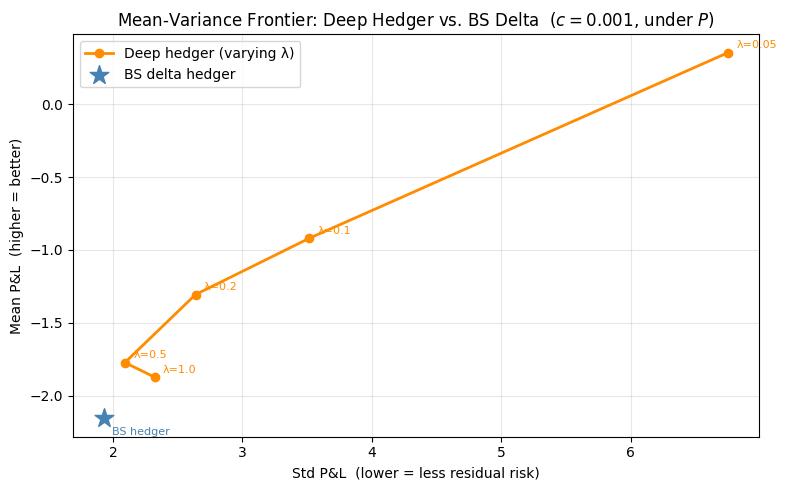

Figure saved: lambda_frontier.png


In [10]:
# ── Mean-variance efficient frontier ──────────────────────────────────────────

lams  = [r['lam']   for r in sweep_results]
means = [r['mean_d'] for r in sweep_results]
stds  = [r['std_d']  for r in sweep_results]

bs_mean = sweep_results[0]['mean_b']
bs_std  = sweep_results[0]['std_b']

fig, ax = plt.subplots(figsize=(8, 5))

# Efficient frontier traced by deep hedger
ax.plot(stds, means, 'o-', color='darkorange', lw=2, label='Deep hedger (varying λ)')

# Annotate each lambda
for lam, m, s in zip(lams, means, stds):
    ax.annotate(f'λ={lam}', xy=(s, m), xytext=(6, 3),
                textcoords='offset points', fontsize=8, color='darkorange')

# BS delta hedger — a single point (policy independent of lambda)
ax.scatter([bs_std], [bs_mean], marker='*', s=200, color='steelblue',
           zorder=5, label=f'BS delta hedger')
ax.annotate('BS hedger', xy=(bs_std, bs_mean), xytext=(6, -12),
            textcoords='offset points', fontsize=8, color='steelblue')

ax.set_xlabel('Std P&L  (lower = less residual risk)')
ax.set_ylabel('Mean P&L  (higher = better)')
ax.set_title(r'Mean-Variance Frontier: Deep Hedger vs. BS Delta  ($c=0.001$, under $P$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lambda_frontier.png', dpi=150)
plt.show()
print('Figure saved: lambda_frontier.png')


### 8b. Entropic Risk Improvement vs $\lambda$

The gap between the BS hedger's entropic risk and the deep hedger's entropic risk
measures how much value the learned correction adds *under each $\lambda$'s own
objective*.  Note that the BS hedger's risk value also changes with $\lambda$
(even though its policy is fixed), because the risk measure itself changes.


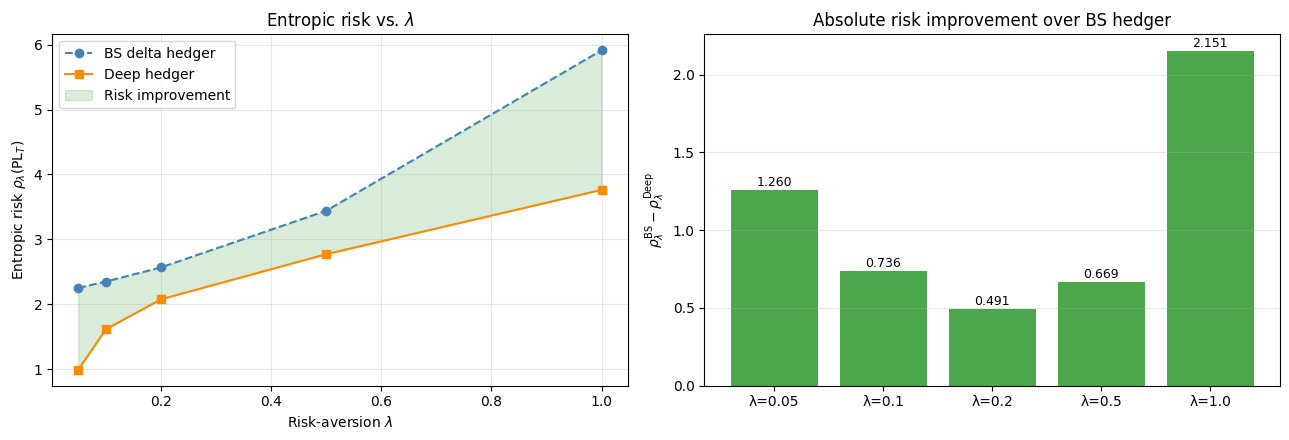

Figure saved: lambda_risk_improvement.png


In [11]:
# ── Entropic risk improvement vs lambda ───────────────────────────────────────

rho_deep = [r['rho_d'] for r in sweep_results]
rho_bs   = [r['rho_b'] for r in sweep_results]
improvement = [b - d for b, d in zip(rho_bs, rho_deep)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: absolute risk values
ax = axes[0]
ax.plot(lams, rho_bs,   'o--', color='steelblue',  label='BS delta hedger')
ax.plot(lams, rho_deep, 's-',  color='darkorange', label='Deep hedger')
ax.fill_between(lams, rho_bs, rho_deep, alpha=0.15, color='green', label='Risk improvement')
ax.set_xlabel(r'Risk-aversion $\lambda$')
ax.set_ylabel(r'Entropic risk $\rho_\lambda(\mathrm{PL}_T)$')
ax.set_title(r'Entropic risk vs. $\lambda$')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: absolute improvement
ax2 = axes[1]
ax2.bar(range(len(lams)), improvement, color='green', alpha=0.7)
ax2.set_xticks(range(len(lams)))
ax2.set_xticklabels([f'λ={l}' for l in lams])
ax2.set_ylabel(r'$\rho_\lambda^{\rm BS} - \rho_\lambda^{\rm Deep}$')
ax2.set_title(r'Absolute risk improvement over BS hedger')
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(improvement):
    ax2.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('lambda_risk_improvement.png', dpi=150)
plt.show()
print('Figure saved: lambda_risk_improvement.png')


### 8c. P&L Distributions Across $\lambda$

Each panel shows the P&L distribution of the deep hedger trained at that $\lambda$,
overlaid with the BS delta hedger.  As $\lambda$ increases the deep hedger's
distribution narrows toward the BS hedger's, reflecting the tighter variance
constraint.


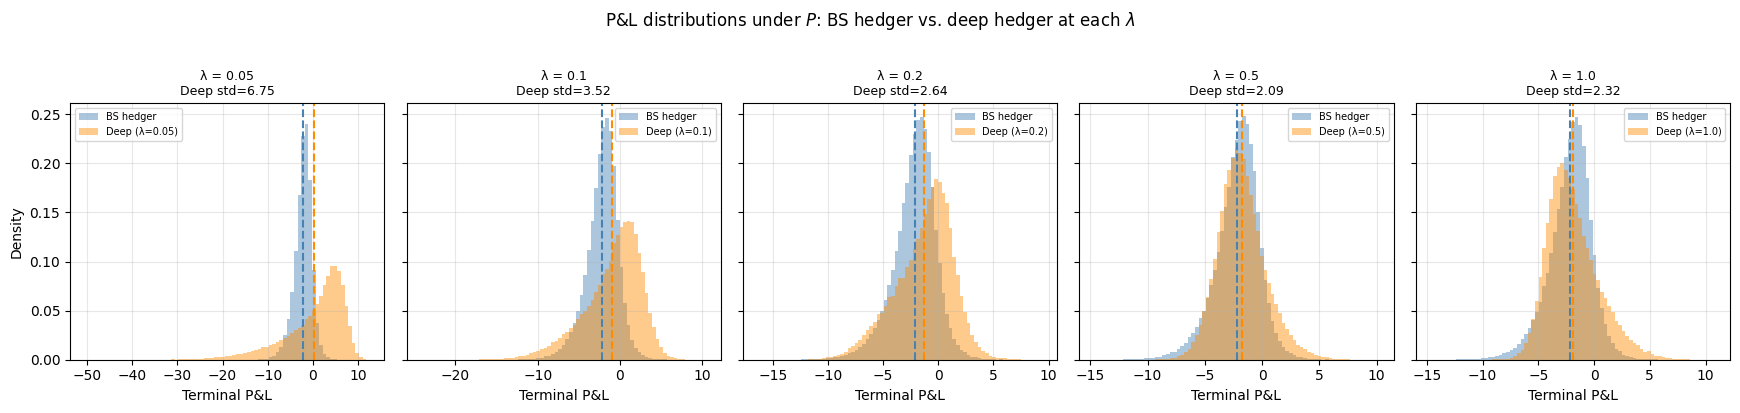

Figure saved: lambda_pnl_grid.png


In [12]:
# ── P&L distribution grid across lambda values ────────────────────────────────

n_lam = len(sweep_results)
fig, axes = plt.subplots(1, n_lam, figsize=(3.5 * n_lam, 4), sharey=True)

for ax, r in zip(axes, sweep_results):
    lo = min(r['pnl_b'].min(), r['pnl_d'].min())
    hi = max(r['pnl_b'].max(), r['pnl_d'].max())
    bins = np.linspace(lo, hi, 80)

    ax.hist(r['pnl_b'], bins=bins, alpha=0.45, density=True,
            color='steelblue', label='BS hedger')
    ax.hist(r['pnl_d'], bins=bins, alpha=0.45, density=True,
            color='darkorange', label=f'Deep (λ={r["lam"]})')

    ax.axvline(r['mean_b'], color='steelblue',  lw=1.5, ls='--')
    ax.axvline(r['mean_d'], color='darkorange', lw=1.5, ls='--')

    ax.set_title(f'λ = {r["lam"]}\nDeep std={r["std_d"]:.2f}', fontsize=9)
    ax.set_xlabel('Terminal P&L')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Density')
plt.suptitle(r'P&L distributions under $P$: BS hedger vs. deep hedger at each $\lambda$',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('lambda_pnl_grid.png', dpi=150)
plt.show()
print('Figure saved: lambda_pnl_grid.png')


## 9. Detailed Analysis at $\lambda = 0.1$

The sweep above gives a high-level picture.  The cells below give a deeper look
at the model trained with `LAMBDA = 0.1` — learning curve, P&L distribution,
correction heatmap, and sample delta paths.

We retrieve the trained model from `sweep_results` rather than re-training.


In [13]:
# ── Retrieve the lambda=0.1 model from the sweep ──────────────────────────────
# Find the sweep result for LAMBDA = 0.1 (or the closest value)
ref = next(r for r in sweep_results if abs(r['lam'] - LAMBDA) < 1e-9)
model = ref['model']
model.eval()
print(f"Using model trained at lambda={ref['lam']}")
print(f"  Deep hedger: mean={ref['mean_d']:.4f}, std={ref['std_d']:.4f}, rho={ref['rho_d']:.4f}")
print(f"  BS hedger:   mean={ref['mean_b']:.4f}, std={ref['std_b']:.4f}, rho={ref['rho_b']:.4f}")


Using model trained at lambda=0.1
  Deep hedger: mean=-0.9201, std=3.5150, rho=1.6132
  BS hedger:   mean=-2.1545, std=1.9314, rho=2.3497


## 10. Evaluation at $\lambda = 0.1$: Deep Hedger vs. BS Delta Hedger

Detailed comparison on 100,000 test paths under $P$ for the $\lambda = 0.1$ model.


In [14]:
# ── Detailed evaluation at lambda = 0.1 ───────────────────────────────────────

pnl_deep_np = ref['pnl_d']
pnl_bs_np   = ref['pnl_b']

def summarise(pnl_np, lam, label):
    rho = entropic_risk(torch.tensor(pnl_np), lam=lam).item()
    print(f"  {label}:")
    print(f"    Mean P&L          : {pnl_np.mean():.4f}")
    print(f"    Std  P&L          : {pnl_np.std():.4f}")
    print(f"    5th-pct tail loss : {float(np.percentile(pnl_np, 5)):.4f}")
    print(f"    Entropic risk rho : {rho:.4f}")
    print()

print(f"Out-of-sample results (100,000 paths under P, lambda={LAMBDA}):")
print()
summarise(pnl_bs_np,   LAMBDA, "BS delta hedger (cost-blind)")
summarise(pnl_deep_np, LAMBDA, "Deep hedger     (cost-aware)")


Out-of-sample results (100,000 paths under P, lambda=0.1):

  BS delta hedger (cost-blind):
    Mean P&L          : -2.1545
    Std  P&L          : 1.9314
    5th-pct tail loss : -5.6208
    Entropic risk rho : 2.3497

  Deep hedger     (cost-aware):
    Mean P&L          : -0.9201
    Std  P&L          : 3.5150
    5th-pct tail loss : -7.7438
    Entropic risk rho : 1.6132



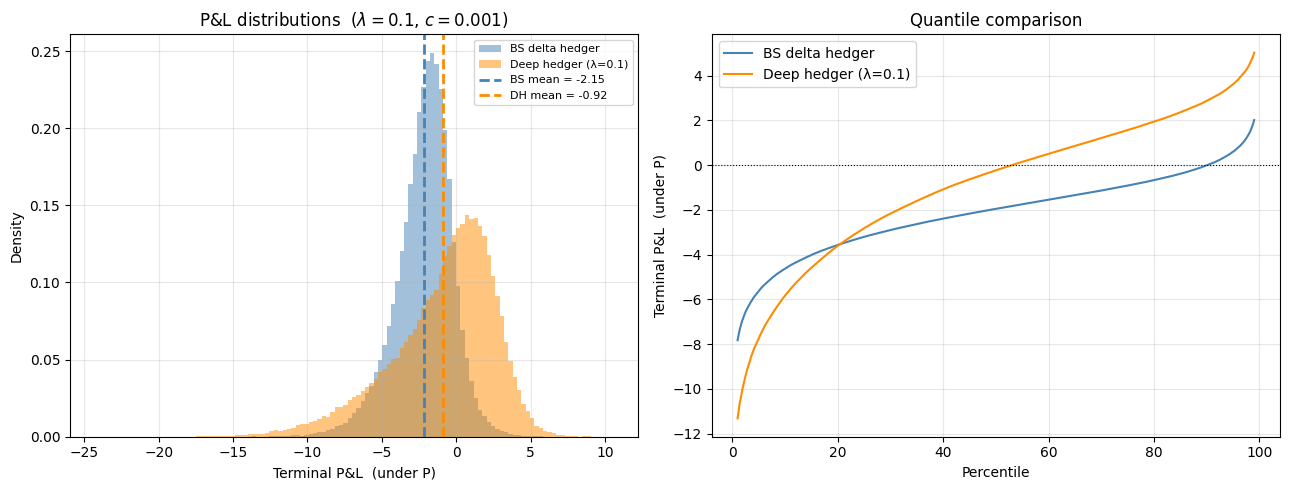

Figure saved: pnl_comparison.png


In [15]:
# ── P&L distribution at lambda=0.1 ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
lo  = min(pnl_bs_np.min(), pnl_deep_np.min())
hi  = max(pnl_bs_np.max(), pnl_deep_np.max())
bins = np.linspace(lo, hi, 120)
ax.hist(pnl_bs_np,   bins=bins, alpha=0.5, label='BS delta hedger',
        color='steelblue', density=True)
ax.hist(pnl_deep_np, bins=bins, alpha=0.5, label='Deep hedger (λ=0.1)',
        color='darkorange', density=True)
ax.axvline(pnl_bs_np.mean(),   color='steelblue',  lw=2, ls='--',
           label=f'BS mean = {pnl_bs_np.mean():.2f}')
ax.axvline(pnl_deep_np.mean(), color='darkorange',  lw=2, ls='--',
           label=f'DH mean = {pnl_deep_np.mean():.2f}')
ax.set_xlabel('Terminal P&L  (under P)')
ax.set_ylabel('Density')
ax.set_title(r'P&L distributions  ($\lambda=0.1$, $c=0.001$)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
quantiles = np.linspace(0.01, 0.99, 500)
ax2.plot(quantiles * 100, np.quantile(pnl_bs_np,   quantiles),
         label='BS delta hedger', color='steelblue')
ax2.plot(quantiles * 100, np.quantile(pnl_deep_np, quantiles),
         label='Deep hedger (λ=0.1)', color='darkorange')
ax2.axhline(0, color='black', lw=0.8, ls=':')
ax2.set_xlabel('Percentile')
ax2.set_ylabel('Terminal P&L  (under P)')
ax2.set_title('Quantile comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pnl_comparison.png', dpi=150)
plt.show()
print('Figure saved: pnl_comparison.png')


## 11. Learned Correction at $\lambda = 0.1$

We visualise $F_\theta(t, \log(S/K), 0)$ over a grid of $(t, S)$ values for
the $\lambda = 0.1$ model.  The correction should be negative near the money
(trade less than BS delta to reduce turnover) and shrink toward zero near maturity.


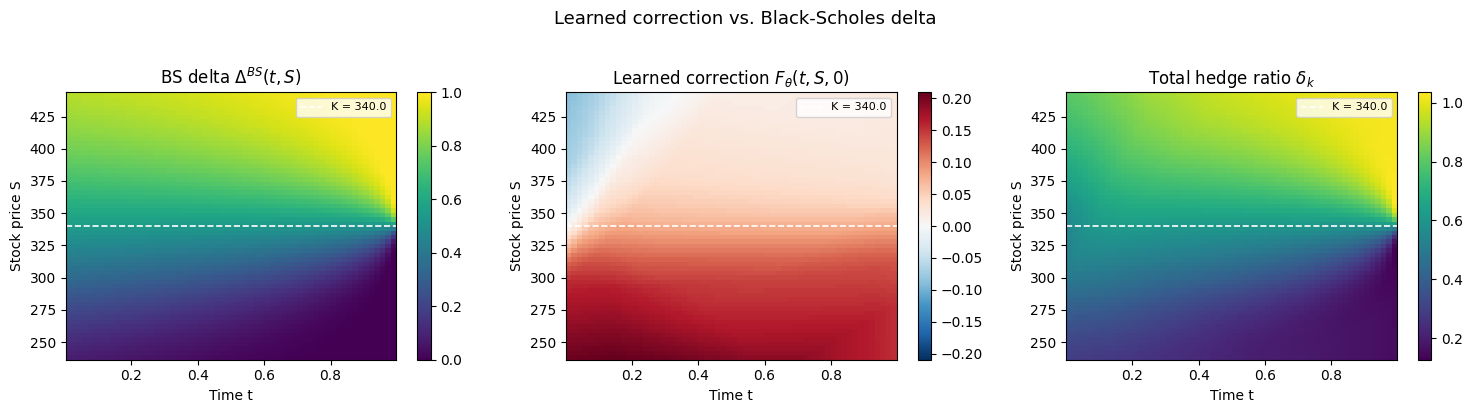

Figure saved: correction_heatmap.png


In [16]:
# ── Visualise the learned correction as a function of (t, S) ──────────────────

model.eval()

# Grid of (time, stock price) values
n_grid = 60
t_grid = np.linspace(0.01, 0.99, n_grid)
S_grid = np.linspace(S0 * 0.7, S0 * 1.3, n_grid)

T_mat, S_mat = np.meshgrid(t_grid, S_grid)   # both shape [n_grid, n_grid]

T_flat = torch.tensor(T_mat.ravel(), dtype=torch.float32, device=device)
S_flat = torch.tensor(S_mat.ravel(), dtype=torch.float32, device=device)
corr_prev = torch.zeros_like(T_flat)   # assume previous correction = 0

with torch.no_grad():
    _, correction_flat, delta_bs_flat = model(T_flat, S_flat, corr_prev)

correction_mat = correction_flat.cpu().numpy().reshape(n_grid, n_grid)
delta_bs_mat   = delta_bs_flat.cpu().numpy().reshape(n_grid, n_grid)
total_delta_mat = delta_bs_mat + correction_mat

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def heatmap(ax, data, title, cmap="RdBu_r", symmetric=False):
    vmax = np.abs(data).max() if symmetric else None
    vmin = -vmax if symmetric else None
    im = ax.pcolormesh(t_grid, S_grid, data, cmap=cmap, vmin=vmin, vmax=vmax,
                       shading="auto")
    plt.colorbar(im, ax=ax)
    ax.axhline(K, color="white", ls="--", lw=1.2, label=f"K = {K}")
    ax.set_xlabel("Time t")
    ax.set_ylabel("Stock price S")
    ax.set_title(title)
    ax.legend(fontsize=8)

heatmap(axes[0], delta_bs_mat,   "BS delta $\\Delta^{BS}(t,S)$",       cmap="viridis")
heatmap(axes[1], correction_mat, "Learned correction $F_\\theta(t,S,0)$",
        cmap="RdBu_r", symmetric=True)
heatmap(axes[2], total_delta_mat,"Total hedge ratio $\\delta_k$",        cmap="viridis")

plt.suptitle("Learned correction vs. Black-Scholes delta", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("correction_heatmap.png", dpi=150)
plt.show()
print("Figure saved: correction_heatmap.png")


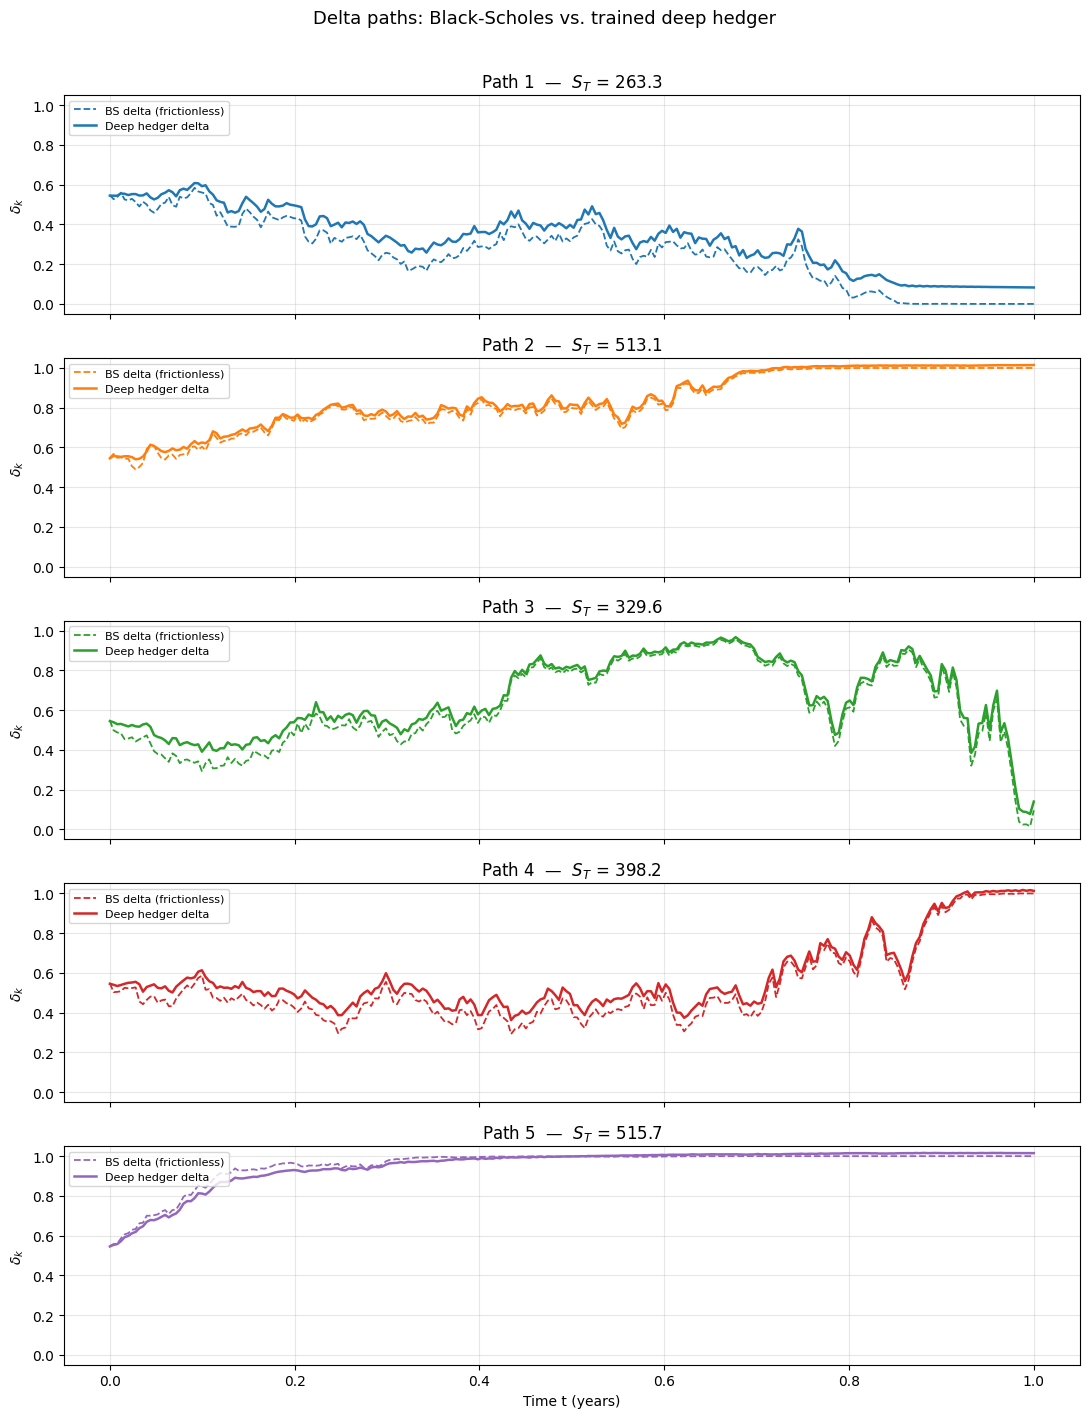

Figure saved: delta_paths.png


In [17]:
# ── Trace hedge ratios on a few sample paths ───────────────────────────────────
# Shows how the deep hedger's delta evolves compared to the BS delta on the same path.

N_SHOW = 5
torch.manual_seed(7)
S_show = simulate_gbm(N_SHOW).to(device)   # shape [N_SHOW, N_STEPS+1]

model.eval()
deep_deltas = np.zeros((N_SHOW, N_STEPS))
bs_deltas   = np.zeros((N_SHOW, N_STEPS))

with torch.no_grad():
    prev_corr  = torch.zeros(N_SHOW, device=device)
    prev_delta = torch.zeros(N_SHOW, device=device)

    for k in range(N_STEPS):
        t_k     = torch.full((N_SHOW,), k / N_STEPS, device=device)
        S_k     = S_show[:, k]
        d_tot, corr_k, d_bs = model(t_k, S_k, prev_corr)

        deep_deltas[:, k] = d_tot.cpu().numpy()
        bs_deltas[:, k]   = d_bs.cpu().numpy()

        prev_corr  = corr_k
        prev_delta = d_tot

t_axis = np.linspace(0, 1, N_STEPS)

fig, axes = plt.subplots(N_SHOW, 1, figsize=(11, 2.8 * N_SHOW), sharex=True)
colors = plt.cm.tab10.colors

for i in range(N_SHOW):
    ax = axes[i]
    ax.plot(t_axis, bs_deltas[i],   color=colors[i], ls="--", lw=1.3,
            label="BS delta (frictionless)")
    ax.plot(t_axis, deep_deltas[i], color=colors[i], lw=1.8,
            label="Deep hedger delta")
    ax.set_ylabel("$\\delta_k$")
    ax.set_title(f"Path {i+1}  —  $S_T$ = {S_show[i, -1].item():.1f}")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

axes[-1].set_xlabel("Time t (years)")
plt.suptitle("Delta paths: Black-Scholes vs. trained deep hedger", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("delta_paths.png", dpi=150)
plt.show()
print("Figure saved: delta_paths.png")


## 12. Effect of Transaction Cost Level (at $\lambda = 0.1$)

We now sweep over the cost rate $c$ at fixed $\lambda = 0.1$, re-training a fresh
network for each $c$.  This shows that the risk improvement of the deep hedger
over the BS delta hedger grows with $c$.

> **Note:** This cell re-trains 6 networks and may take a few minutes.


Cost sweep at lambda=0.1: 6 levels, 1000 steps each under P ...

  c=0.0000 | BS rho=0.17318 | Deep rho=-0.38781 | Improvement=0.56099
  c=0.0005 | BS rho=1.25626 | Deep rho=0.62803 | Improvement=0.62822
  c=0.0010 | BS rho=2.34966 | Deep rho=1.61141 | Improvement=0.73825
  c=0.0020 | BS rho=4.56738 | Deep rho=3.56944 | Improvement=0.99793
  c=0.0050 | BS rho=11.46428 | Deep rho=13.08293 | Improvement=-1.61865
  c=0.0100 | BS rho=23.73573 | Deep rho=23.00660 | Improvement=0.72913


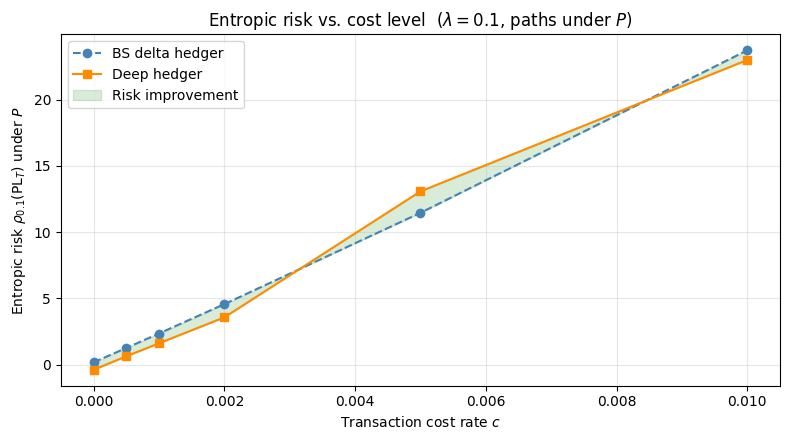

Figure saved: cost_sweep.png


In [18]:
# ── Sweep over transaction cost levels at lambda=0.1 ──────────────────────────

cost_levels   = [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01]
N_TRAIN_SWEEP = 1_000

risk_bs_sweep   = []
risk_deep_sweep = []

print(f"Cost sweep at lambda={LAMBDA}: {len(cost_levels)} levels, "
      f"{N_TRAIN_SWEEP} steps each under P ...")
print()

for c in cost_levels:
    m_sw  = CorrectionNet(hidden_size=32).to(device)
    opt_sw = optim.Adam(m_sw.parameters(), lr=LR)

    m_sw.train()
    for step in range(N_TRAIN_SWEEP):
        S_b = simulate_gbm(M_PATHS, mu=MU).to(device)
        opt_sw.zero_grad()
        _, risk_sw = simulate_episode(m_sw, S_b, cost_rate=c, lam=LAMBDA)
        risk_sw.backward()
        torch.nn.utils.clip_grad_norm_(m_sw.parameters(), 1.0)
        opt_sw.step()

    m_sw.eval()
    with torch.no_grad():
        _, r_deep = simulate_episode(m_sw,      S_test, cost_rate=c, lam=LAMBDA)
        _, r_bs   = simulate_episode(bs_hedger, S_test, cost_rate=c, lam=LAMBDA)

    risk_deep_sweep.append(r_deep.item())
    risk_bs_sweep.append(r_bs.item())

    print(f"  c={c:.4f} | BS rho={r_bs.item():.5f} | "
          f"Deep rho={r_deep.item():.5f} | "
          f"Improvement={r_bs.item()-r_deep.item():.5f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cost_levels, risk_bs_sweep,   'o--', color='steelblue',  label='BS delta hedger')
ax.plot(cost_levels, risk_deep_sweep, 's-',  color='darkorange', label='Deep hedger')
ax.fill_between(cost_levels, risk_bs_sweep, risk_deep_sweep,
                alpha=0.15, color='green', label='Risk improvement')
ax.set_xlabel('Transaction cost rate $c$')
ax.set_ylabel(r'Entropic risk $\rho_{0.1}(\mathrm{PL}_T)$ under $P$')
ax.set_title(r'Entropic risk vs. cost level  ($\lambda=0.1$, paths under $P$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cost_sweep.png', dpi=150)
plt.show()
print('Figure saved: cost_sweep.png')


## 13. Summary

This notebook implemented the Bühler et al. deep hedging framework for a short
European call under GBM with proportional transaction costs, using the
**residual correction architecture**:

$$\delta_k = \Delta^{\text{BS}}(t_k, S_{t_k}) + F_\theta(t_k, \log(S_{t_k}/K), \epsilon_{k-1})$$

All simulation and risk measurement was performed under the **physical measure $P$**
with drift $\mu = 0.08$.

### Key findings

**Lambda sweep** (Section 7–8):
- The deep hedger traces out an efficient frontier in mean-std space.
- Small $\lambda$: aggressive cost saving, higher residual variance.
- Large $\lambda$: tight hedging, variance close to BS, smaller mean improvement.
- The BS delta hedger lies off the efficient frontier — it is suboptimal for any $\lambda > 0$.
- The entropic risk improvement over BS is largest at small $\lambda$ and shrinks as $\lambda \to \infty$.

**Detailed analysis at $\lambda = 0.1$** (Sections 9–11):
- The correction $F_\theta$ is negative near the money — the network learns to
  under-trade relative to BS delta, reducing turnover to save transaction costs.
- The correction shrinks toward zero near maturity and far from the money.

**Cost sweep** (Section 12):
- The risk improvement over BS grows with $c$.
